**STAT 453: Introduction to Deep Learning and Generative Models (Fall 2026)**

Instructor: Ben Lengerich


Useful resources from previous years:

Course website http://pages.stat.wisc.edu/~sraschka/teaching/stat453-ss2020/  

GitHub repository https://github.com/rasbt/stat453-deep-learning-ss20

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AdaptInfer/dgm-fall-2026/blob/main/assets/hw/hw1/STAT453_hw01.ipynb)

## How to Submit

1. **Run every cell top to bottom before exporting**, so your output isn't stale:
   - Jupyter: `Kernel → Restart & Run All`
   - Colab: `Runtime → Restart and run all`
2. **Export this notebook to PDF:**
   - Colab: `File → Print → Save as PDF`
   - Local Jupyter: `File → Save and Export Notebook As → PDF`, or from a terminal: `jupyter nbconvert --to webpdf --allow-chromium-download STAT453_hw01.ipynb`
3. **Check the PDF** — make sure plots aren't cut off at page edges and every cell that should have output actually shows it.
4. **Name the file `<netid>_hw1.pdf`** (e.g. `blengerich_hw1.pdf`).
5. **Submit the PDF on Canvas** by the deadline listed on the [homework page](https://adaptinfer.org/dgm-fall-2026/homework/).

# HW 1: Math Foundations + the Perceptron Algorithm in "Just" Python (50 pts)

This assignment has two parts, tied to lecture material from 9/10 through 9/17:

- **Part A (15 pts)** is a short statistics / linear algebra / calculus warm-up. You will implement small pure-Python helper functions and use them to check a hand-derived gradient formula against a numerical (finite-difference) estimate. This previews the gradient descent update rule we cover in lecture on 9/17 &mdash; and sets up a contrast with the perceptron's update rule in Part B.
- **Part B (35 pts)** asks you to implement Frank Rosenblatt's Perceptron for binary classification (0/1 labels) on a new dataset, reusing some of the helper functions from Part A.

For **both parts**, you should only use "basic" or "vanilla" Python. No `import`s from PyTorch or NumPy are permitted anywhere in this notebook (only `matplotlib` and `random`, which are already imported for you).

A good portion of the code is already written and you don't need to change it. However, you are encouraged to read and understand it. Cells marked `# <your code>` are the parts you need to fill in; most sections end with a small self-check cell using `assert` statements &mdash; if it runs without an `AssertionError` and prints `looks good!`, you're on the right track (though passing the self-checks does not guarantee full credit).

### Important!

**Due Friday, September 18 at 11:59 PM. The homework assignment should be submitted via Canvas.**

- Please submit the `.ipynb` file with your solution as well as an HTML version (use `File -> Export as -> HTML`) as a backup in case we cannot open your .ipynb on our computer.

- I recommend using the conda package manager for installing Python 3.7 or higher versions and Jupyter Notebook (or Jupyter Lab). You may find the lecture notes from a machine learning class (https://github.com/rasbt/stat479-machine-learning-fs19/blob/master/03_python/03-python__notes.pdf, Section 3) helpful.

- Also consider this YouTube tutorial for a more visual setup guide for conda: https://www.youtube.com/watch?v=YJC6ldI3hWk (Python Tutorial: Anaconda - Installation and Using Conda). Please reach out to the TA or me if you need any help or have questions.

## 0) Imports

**No modification required.** You should execute this code, but it is recommended not to make any alterations here.

In [3]:
import random
import matplotlib.pyplot as plt
%matplotlib inline

## Part A: Statistics, Linear Algebra, and Calculus Warm-Up (15 pts)

### A.1) Linear algebra: vector operations (5 pts)

Implement three pure-Python helper functions that operate on vectors represented as plain Python lists. **You will reuse all three inside the `Perceptron` class in Part B**: `dot` for the pre-activation, and `vector_add`/`scalar_mult` for the weight-update step in `fit`. Make sure they work correctly for vectors of any length.

- `dot(u, v)`: returns the dot product $\sum_i u_i v_i$.
- `vector_add(u, v)`: returns the element-wise sum of `u` and `v`, as a list.
- `scalar_mult(c, v)`: returns `v` scaled by the number `c`, as a list.

In [4]:
def dot(u, v):
    return sum(a * b for a, b in zip(u,v))

def vector_add(u, v):
    return [a + b for a, b in zip(u, v)]

def scalar_mult(c, v):
    return [c * a for a in v]


Run the self-check below before moving on.

In [5]:
assert dot([1, 2, 3], [4, 5, 6]) == 32
assert vector_add([1, 2], [3, 4]) == [4, 6]
assert scalar_mult(2, [1, -1, 0.5]) == [2, -2, 1.0]
print('A.1 looks good!')

A.1 looks good!


### A.2) Calculus: hand-derived vs. numerical gradients (5 pts)

Consider a single **linear unit** (no threshold) that computes $z = w \cdot x + b$ for a single example $(x, y)$, scored with the squared-error loss

$$L(w, b) = (y - z)^2.$$

**(a) By hand:** derive $\partial L / \partial w_j$ (for each weight $w_j$) and $\partial L / \partial b$. Write your derivation and final formulas in the markdown cell below (LaTeX is fine, but plain text is okay too). This is exactly the kind of gradient used for gradient descent, which we cover in lecture on 9/17 &mdash; contrast it with the perceptron's update rule that you'll implement in Part B, which does *not* come from differentiating a loss function.

**(b) In code:** implement `analytic_gradient(x, y, w, b)` using the formula you derived in (a). Then, without taking any analytic derivatives in code, implement `numerical_gradient(x, y, w, b, h=1e-5)` to check that formula using centered finite differences: perturb each parameter by $\pm h$, recompute $L$, and return the estimated `(grad_w, grad_b)`. Confirm the two agree on the provided test point.

**Your derivation for (a):** Using the chain rule, the derivative with respect to each weight is the derivative of the loss with respect to z multiplied by the derivative of z with respect to that weight.

Since L = (y - z)^2, dL/dz = -2(y - z). Since z = w·x + b, dz/dwj = xj. Therefore, dL/dwj = -2(y - z)xj.

For the bias, dz/db = 1, so dL/db = -2(y - z).



In [6]:
def squared_error_loss(x, y, w, b):
    z = dot(w, x) + b
    return (y - z) ** 2

def analytic_gradient(x, y, w, b):
    z = dot(w, x) + b
    grad_b = -2 * (y - z)
    grad_w = [grad_b * xj for xj in x]
    return grad_w, grad_b

def numerical_gradient(x, y, w, b, h=1e-5):
    grad_w = []

    for j in range(len(w)):
        w_plus = w.copy()
        w_minus = w.copy()

        w_plus[j] += h
        w_minus[j] -= h

        loss_plus = squared_error_loss(x, y, w_plus, b)
        loss_minus = squared_error_loss(x, y, w_minus, b)

        grad = (loss_plus - loss_minus) / (2 * h)
        grad_w.append(grad)

    loss_plus = squared_error_loss(x, y, w, b + h)
    loss_minus = squared_error_loss(x, y, w, b - h)

    grad_b = (loss_plus - loss_minus) / (2 * h)

    return grad_w, grad_b

In [7]:
x_test = [1.0, -2.0]
y_test = 1.0
w_test = [0.3, -0.1]
b_test = 0.2

ga_w, ga_b = analytic_gradient(x_test, y_test, w_test, b_test)
gn_w, gn_b = numerical_gradient(x_test, y_test, w_test, b_test)

print('analytic gradient:', ga_w, ga_b)
print('numeric  gradient:', gn_w, gn_b)

for a, n in zip(ga_w, gn_w):
    assert abs(a - n) < 1e-3, 'gradient w.r.t. w does not match — recheck your derivation'
assert abs(ga_b - gn_b) < 1e-3, 'gradient w.r.t. b does not match — recheck your derivation'
print('A.2 looks good!')

analytic gradient: [-0.6000000000000001, 1.2000000000000002] -0.6000000000000001
numeric  gradient: [-0.6000000000006, 1.2000000000012] -0.6000000000006
A.2 looks good!


### A.3) Statistics: mean, variance, and standardization (5 pts)

Implement `mean(values)` and `variance(values)` (**population** variance, i.e. divide by $n$, not $n-1$) for a list of numbers, and use them to implement `standardize(values)`, which converts a list of numbers to $z$-scores: $z_i = (x_i - \bar{x}) / \sigma$.

You'll use `standardize` in Part B to preprocess the two gemstone features before training the perceptron.

**Short answer (1-2 sentences, in the markdown cell below):** the perceptron's weight update rule is $w \leftarrow w + (y - \hat{y})\, x$. Given this rule, why might standardizing the input features help training behave more reliably, especially when the two features are on very different numeric scales?

In [8]:
def mean(values):
    return sum(values) / len(values)

def variance(values):
    avg = mean(values)
    return sum((x - avg) ** 2 for x in values) / len(values)

def standardize(values):
    """Return a new list with each value converted to a z-score,
    using this list's own mean and variance."""
    avg = mean(values)
    std = variance(values) ** 0.5
    return [(x - avg) / std for x in values]


In [9]:
vals = [2.0, 4.0, 4.0, 4.0, 5.0, 5.0, 7.0, 9.0]
assert abs(mean(vals) - 5.0) < 1e-9
assert abs(variance(vals) - 4.0) < 1e-9
z = standardize(vals)
assert abs(mean(z)) < 1e-9
assert abs(variance(z) - 1.0) < 1e-9
print('A.3 looks good!')

A.3 looks good!


**Your answer:** Standardizing the features puts them on a similar scale, so one feature does not cause much larger weight updates just because its values are bigger. This helps the perceptron train more consistently and reliably.

## Part B: The Perceptron Algorithm in "Just" Python (35 pts)

You'll implement Frank Rosenblatt's Perceptron for binary classification (0/1 labels) on a new dataset: sorting **gemstones** as genuine (`1`) or synthetic (`0`) using two measured properties, `refractive_index` and `inclusion_density`.

As in Part A, you may only use "basic"/"vanilla" Python for this part &mdash; no `import`s from PyTorch or NumPy. **Reuse your `dot` function from Part A.1** inside the `Perceptron` class below.

Note that you are asked to use the overall structure of the `Perceptron` Python `class` provided. It may seem like overkill for such a simple model, but it mirrors the `forward`/`backward`-style structure we'll use for PyTorch models later in the course.

One twist this year: unlike a textbook toy dataset, these gemstones are **not perfectly linearly separable** &mdash; a few synthetic stones happen to measure like genuine ones, and vice versa. Watch what that does to training below.

### 1) Loading the dataset

**No modification required.** You should execute this code and are encouraged to explore it further, but it is recommended not to make any alterations here.

In [10]:
# Fetch the dataset if it's not already sitting next to this notebook
# (e.g. when running in Google Colab).
import os
import urllib.request

DATA_URL = "https://raw.githubusercontent.com/AdaptInfer/dgm-fall-2026/main/assets/hw/hw1/dataset.csv"
if not os.path.exists("dataset.csv"):
    urllib.request.urlretrieve(DATA_URL, "dataset.csv")


In [11]:
raw_features = []
labels = []

with open('./dataset.csv', 'r') as f:
    next(f)  # skip header: refractive_index,inclusion_density,label
    for line in f:
        line = line.strip()
        if not line:
            continue
        values = line.split(',')
        raw_features.append([float(values[0]), float(values[1])])
        labels.append(int(values[2]))

print(len(raw_features), len(labels))

150 150


Standardize each feature column separately using **your** `mean`/`variance`-based `standardize` function from Part A.3, then reassemble into per-sample feature vectors.

In [12]:
col0 = [row[0] for row in raw_features]
col1 = [row[1] for row in raw_features]

col0_std = standardize(col0)
col1_std = standardize(col1)

features = [[a, b] for a, b in zip(col0_std, col1_std)]

In [13]:
random.seed(453)

idx = list(range(len(features)))
random.shuffle(idx)

X_train = [features[i] for i in idx[:100]]
y_train = [labels[i] for i in idx[:100]]
X_test = [features[i] for i in idx[100:]]
y_test = [labels[i] for i in idx[100:]]

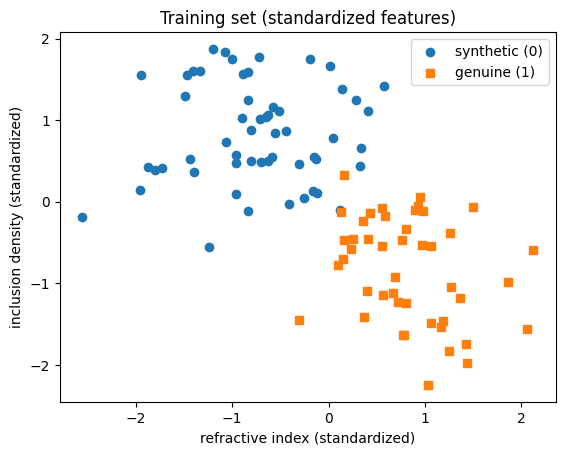

In [14]:
plt.scatter([x[0] for x, yi in zip(X_train, y_train) if yi == 0],
            [x[1] for x, yi in zip(X_train, y_train) if yi == 0],
            label='synthetic (0)', marker='o')

plt.scatter([x[0] for x, yi in zip(X_train, y_train) if yi == 1],
            [x[1] for x, yi in zip(X_train, y_train) if yi == 1],
            label='genuine (1)', marker='s')

plt.title('Training set (standardized features)')
plt.xlabel('refractive index (standardized)')
plt.ylabel('inclusion density (standardized)')
plt.legend()
plt.show()

### 2) Defining the Perceptron model

Complete the `Perceptron` class below.

- `net_input(x)`: the pre-activation $z = w \cdot x + b$ (use your `dot` function).
- `activation(z)`: the unit-step function, returning `1` if `z > 0` else `0`.
- `predict(x, use_pocket=False)`: normally calls `net_input` then `activation`. If `use_pocket=True`, do the equivalent computation using `self.best_weights`/`self.best_bias` instead of `self.weights`/`self.bias`.
- `fit(X, y, epochs)`: runs the standard perceptron update rule for the given number of epochs. **In addition to updating `self.weights`/`self.bias` as usual, also track the number of misclassifications made *during* each epoch**, and keep a "pocket" copy of the best (lowest-error) weights and bias seen across all epochs so far, in `self.best_weights` / `self.best_bias` / `self.best_errors`. Return the list of per-epoch misclassification counts.
- `evaluate(X, y, use_pocket=False)`: returns prediction accuracy on `(X, y)`. If `use_pocket=True`, temporarily use `self.best_weights`/`self.best_bias` instead of the current (final) weights.

Keeping a "pocket" copy of the best weights matters this year because the data isn't perfectly separable: the plain perceptron rule keeps adjusting its weights forever, and the final-epoch weights are not necessarily the best ones it ever found.

In [15]:
class Perceptron():
    def __init__(self, num_features):
        self.weights = [0] * num_features
        self.bias = 0
        self.best_weights = list(self.weights)
        self.best_bias = self.bias
        self.best_errors = float('inf')

    def net_input(self, x):
        return dot(self.weights, x) + self.bias

    def activation(self, z):
        return 1 if z > 0 else 0

    def predict(self, x, use_pocket=False):
        if use_pocket:
            z = dot(self.best_weights, x) + self.best_bias
        else:
            z = self.net_input(x)
        return self.activation(z)

    def fit(self, X, y, epochs):
        error_history = []
        for e in range(epochs):
            errors = 0
            for xi, yi in zip(X, y):
                prediction = self.predict(xi)
                if prediction != yi:
                  self.weights = vector_add(self.weights, scalar_mult(yi - prediction, xi))
                  self.bias = self.bias + (yi - prediction)
                  errors += 1
            error_history.append(errors)
            if errors < self.best_errors:
                self.best_weights = list(self.weights)
                self.best_bias = self.bias
                self.best_errors = errors
        return error_history

    def evaluate(self, X, y, use_pocket=False):
        correct = 0
        for xi, yi in zip(X, y):
            prediction = self.predict(xi, use_pocket)
            if prediction == yi:
                correct += 1

        accuracy = correct / len(X)
        return accuracy

### 3) Training the Perceptron

Train the perceptron for **10 epochs** and print out the final weight parameters and bias, as well as the pocketed (best) weights, bias, and error count.

In [16]:
ppn = Perceptron(num_features=2)
error_history = ppn.fit(X_train, y_train, epochs=10)

print('final weights:', ppn.weights, 'final bias:', ppn.bias)
print('pocket weights:', ppn.best_weights, 'pocket bias:', ppn.best_bias, 'pocket errors:', ppn.best_errors)

final weights: [1.734678870038518, -3.2402080532251825] final bias: 0
pocket weights: [2.1357466393320936, -2.2270715471371676] pocket bias: 0 pocket errors: 4


### 4) Learning curve

**No modification required** for the plot below &mdash; it plots the number of misclassifications per epoch (`error_history`, returned by your `fit`) against the epoch number. Run it, then answer in the markdown cell that follows: is training monotonically improving? Briefly describe what you see (1-2 sentences) and relate it to whether this year's dataset is linearly separable.

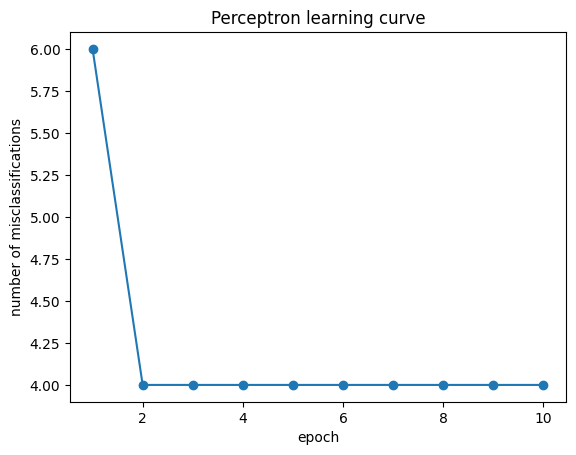

In [17]:
##########################
### Learning curve
##########################

plt.plot(range(1, len(error_history) + 1), error_history, marker='o')
plt.title('Perceptron learning curve')
plt.xlabel('epoch')
plt.ylabel('number of misclassifications')
plt.show()

**Your observation:** Training improves significantly after the first epoch, with misclassifications dropping from 6 to 4. After that, the number of misclassifications stays at 4 for the remaining epochs. This shows that the perceptron improves quickly but does not reach zero errors, which is consistent with the dataset not being perfectly linearly separable.

### 5) Evaluating the model

Compute the prediction accuracy (in percent) for both the training set and the test set, using both the final weights and the pocketed weights.

In [22]:
train_acc_final = ppn.evaluate(X_train, y_train)
test_acc_final = ppn.evaluate(X_test, y_test)
print('Train set accuracy (final):  %.2f%%' % (train_acc_final * 100))
print('Test set accuracy (final):   %.2f%%' % (test_acc_final * 100))

Train set accuracy (final):  98.00%
Test set accuracy (final):   98.00%


In [23]:
train_acc_pocket = ppn.evaluate(X_train, y_train, use_pocket=True)
test_acc_pocket = ppn.evaluate(X_test, y_test, use_pocket=True)
print('Train set accuracy (pocket): %.2f%%' % (train_acc_pocket * 100))
print('Test set accuracy (pocket):  %.2f%%' % (test_acc_pocket * 100))

Train set accuracy (pocket): 98.00%
Test set accuracy (pocket):  96.00%


**Which set of weights generalizes better to the test set here, and does that match what you'd expect given the learning curve you plotted above?** The final weights generalize better to the test set here, with 98% accuracy compared with 96% for the pocket weights. This is not necessarily what I would expect from the pocket method because the pocket keeps the weights from the epoch with the fewest training errors, but in this particular train/test split, the final weights happened to perform better on the test set.

### 6) Decision boundary

The scaffolding below makes 2 scatterplots (training set and test set, using the standardized features) and will draw the perceptron's decision boundary (using the **final** weights) on each one.

**The point of this section:** your `predict` method (which you completed above) classifies a point `x` as class 1 exactly when `net_input(x) = w · x + b > 0`. The *decision boundary* is simply the line where that switch happens, i.e. where `net_input(x) = 0` &mdash; every point on one side of this line gets predicted 0, every point on the other side gets predicted 1. Because `net_input` is linear in `x`, that boundary is a straight line in 2D (this is why we call it a *linear* classifier).

**You only need to fill in `boundary_points`**: given the weights `w`, bias `b`, and a 2-element range of `x0` values `x_range = [x0_min, x0_max]`, return `(x0_vals, x1_vals)` where `x1_vals` are the `x1` values that put each corresponding `x0` exactly on that boundary &mdash; i.e. solve `w[0]*x0 + w[1]*x1 + b = 0` for `x1`, for each `x0` in `x_range`. (Compare this to your `net_input` method: you're finding exactly the inputs where it evaluates to 0.)

In [ ]:
##########################
### 2D Decision Boundary
##########################

def boundary_points(w, b, x_range):
    # The decision boundary is where net_input(x) = w[0]*x0 + w[1]*x1 + b = 0
    # (the same net_input you implemented in the Perceptron class above).
    # Solve that equation for x1 in terms of x0:
    x0_vals = list(x_range)
    x1_vals = x1_vals = [(-w[0] * x0 - b) / w[1] for x0 in x0_vals]
    return x0_vals, x1_vals

x0_range = [min(x[0] for x in features) - 0.5, max(x[0] for x in features) + 0.5]
bx, by = boundary_points(ppn.weights, ppn.bias, x0_range)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)

for ax, X_set, y_set, title in [(axes[0], X_train, y_train, 'Training set'),
                                 (axes[1], X_test, y_test, 'Test set')]:
    ax.scatter([x[0] for x, yi in zip(X_set, y_set) if yi == 0],
               [x[1] for x, yi in zip(X_set, y_set) if yi == 0],
               label='synthetic (0)', marker='o')
    ax.scatter([x[0] for x, yi in zip(X_set, y_set) if yi == 1],
               [x[1] for x, yi in zip(X_set, y_set) if yi == 1],
               label='genuine (1)', marker='s')
    ax.plot(bx, by, 'k-', label='decision boundary')
    ax.set_title(title)
    ax.set_xlabel('refractive index (standardized)')
    ax.legend()

axes[0].set_ylabel('inclusion density (standardized)')
plt.tight_layout()
plt.show()

Attribution: Ben Lengerich, Yiqiao Zhong, Sebastian Raschka, Baiheng Chen